## Import

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from collections import Counter
from sklearn.model_selection import train_test_split

## LOAD DATASET (EDA ONLY - NO AUGMENT)

In [2]:
eda_transform = transforms.ToTensor()

eda_dataset = datasets.ImageFolder(
    root="../DataTrain",
    transform=eda_transform
)

print("Total data:", len(eda_dataset))
print("Classes:", eda_dataset.classes)


Total data: 999
Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## EDA

Class distribution: Counter({0: 100, 1: 100, 2: 100, 3: 100, 4: 100, 6: 100, 7: 100, 8: 100, 9: 100, 5: 99})


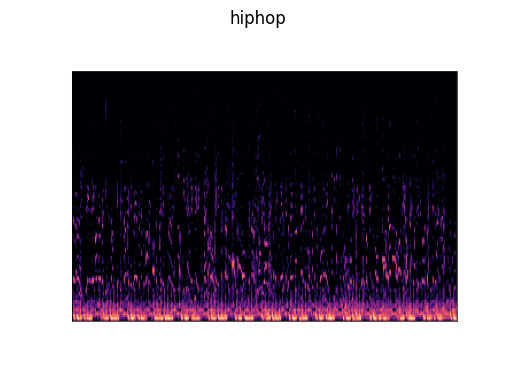

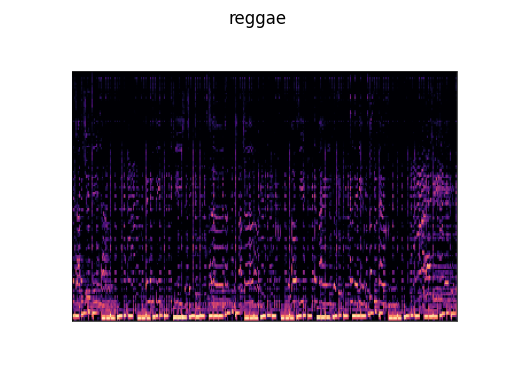

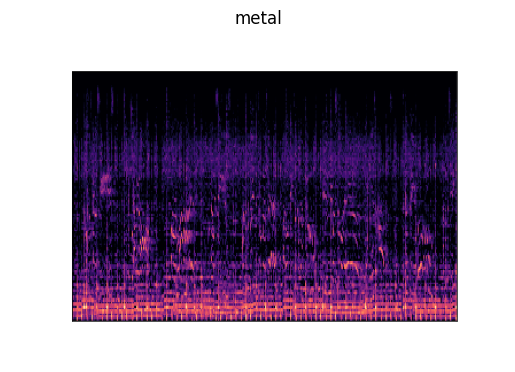

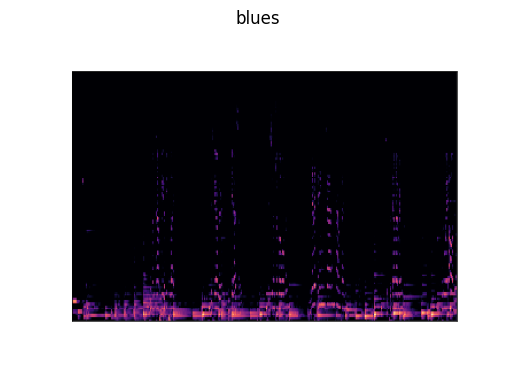

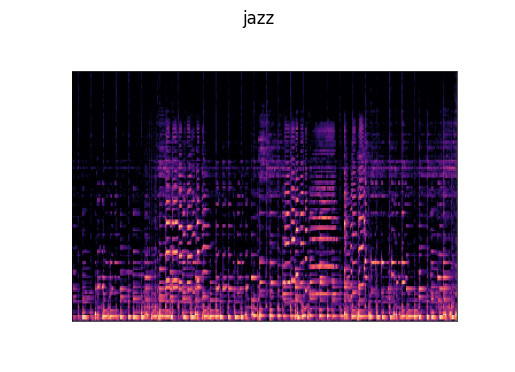

Unique image sizes: {torch.Size([3, 288, 432])}


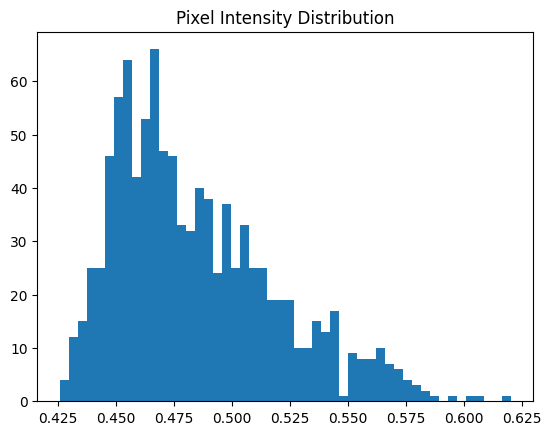

In [3]:
# 🔹 3.1 Class distribution
labels = eda_dataset.targets
class_counts = Counter(labels)
print("Class distribution:", class_counts)

# 🔹 3.2 Visualisasi sample
classes = eda_dataset.classes

for i in range(5):
    img, label = eda_dataset[random.randint(0, len(eda_dataset)-1)]
    plt.imshow(img.permute(1,2,0))
    plt.title(classes[label])
    plt.axis("off")
    plt.show()

# 🔹 3.3 Cek ukuran gambar
sizes = [img.shape for img, _ in eda_dataset]
print("Unique image sizes:", set(sizes))

# 🔹 3.4 Distribusi pixel
all_pixels = []

for img, _ in eda_dataset:
    all_pixels.append(img.mean().item())

plt.hist(all_pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()


## DATA CLEANING (FIX MISSING FILE)

In [4]:
valid_samples = []

for path, label in eda_dataset.samples:
    if os.path.exists(path):
        valid_samples.append((path, label))

eda_dataset.samples = valid_samples
eda_dataset.targets = [s[1] for s in valid_samples]

print("After cleaning:", len(eda_dataset))

After cleaning: 999


## SPLIT DATA (STRATIFIED)

In [5]:
targets = np.array(eda_dataset.targets)
indices = np.arange(len(eda_dataset))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    stratify=targets,
    random_state=42
)

print("Train size:", len(train_idx))
print("Val size:", len(val_idx))

Train size: 849
Val size: 150


## Dataset + Transform

In [6]:
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms

# base dataset (tanpa transform dulu)
base_dataset = datasets.ImageFolder(root="../DataTrain")

# transform
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    root="../DataTrain",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root="../DataTrain",
    transform=val_transform
)

train_dataset = Subset(train_dataset, train_idx)
val_dataset   = Subset(val_dataset, val_idx)

## DataLoader

In [7]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Model (resnet18)

In [8]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(pretrained=True)

num_classes = len(base_dataset.classes)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

model = model.to(device)

c:\Users\User\anaconda3\envs\pytorch\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\pytorch\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Loss & Optimizer

In [9]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

## Training Loop + Validation + Early Stopping

In [10]:
num_epochs = 15

train_losses = []
val_losses = []

best_val_loss = float("inf")
patience = 3
counter = 0

for epoch in range(num_epochs):
    # ===== TRAIN =====
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

    val_loss = running_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch [1/15] | Train Loss: 2.0730 | Val Loss: 1.8385
Epoch [2/15] | Train Loss: 1.5823 | Val Loss: 1.3720
Epoch [3/15] | Train Loss: 1.2441 | Val Loss: 1.0035
Epoch [4/15] | Train Loss: 0.9802 | Val Loss: 0.9071
Epoch [5/15] | Train Loss: 0.8056 | Val Loss: 0.8921
Epoch [6/15] | Train Loss: 0.6559 | Val Loss: 0.7430
Epoch [7/15] | Train Loss: 0.5632 | Val Loss: 0.8134
Epoch [8/15] | Train Loss: 0.4509 | Val Loss: 0.8312
Epoch [9/15] | Train Loss: 0.3608 | Val Loss: 0.8524
Early stopping triggered


## Evaluasi

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

def evaluate_model(model, loader, device="cpu", class_names=None):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    print("Accuracy:", acc)
    print("\nClassification Report")

    if class_names:
        print(classification_report(all_labels, all_preds, target_names=class_names))
    else:
        print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)

    print("\nConfusion Matrix")
    print(cm)

    return acc, cm

evaluate_model(model, val_loader, device, base_dataset.classes)

Accuracy: 0.7333333333333333

Classification Report
              precision    recall  f1-score   support

       blues       0.69      0.60      0.64        15
   classical       0.83      1.00      0.91        15
     country       0.77      0.67      0.71        15
       disco       0.91      0.67      0.77        15
      hiphop       0.72      0.87      0.79        15
        jazz       1.00      0.80      0.89        15
       metal       0.88      0.93      0.90        15
         pop       0.43      0.87      0.58        15
      reggae       0.80      0.53      0.64        15
        rock       0.67      0.40      0.50        15

    accuracy                           0.73       150
   macro avg       0.77      0.73      0.73       150
weighted avg       0.77      0.73      0.73       150


Confusion Matrix
[[ 9  1  0  1  0  0  0  2  2  0]
 [ 0 15  0  0  0  0  0  0  0  0]
 [ 2  0 10  0  0  0  0  2  0  1]
 [ 0  0  0 10  2  0  0  3  0  0]
 [ 0  0  0  0 13  0  0  2  0  0]
 [ 2  

(0.7333333333333333,
 array([[ 9,  1,  0,  1,  0,  0,  0,  2,  2,  0],
        [ 0, 15,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 2,  0, 10,  0,  0,  0,  0,  2,  0,  1],
        [ 0,  0,  0, 10,  2,  0,  0,  3,  0,  0],
        [ 0,  0,  0,  0, 13,  0,  0,  2,  0,  0],
        [ 2,  1,  0,  0,  0, 12,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 14,  0,  0,  1],
        [ 0,  0,  1,  0,  1,  0,  0, 13,  0,  0],
        [ 0,  1,  0,  0,  2,  0,  0,  3,  8,  1],
        [ 0,  0,  2,  0,  0,  0,  2,  5,  0,  6]]))

## Plot Learning Curve

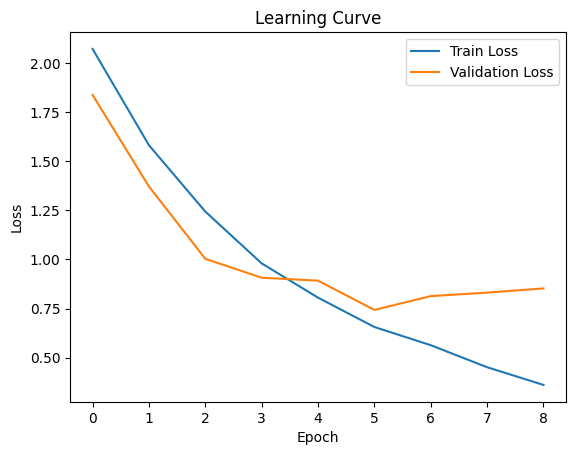

In [12]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()

plt.show()

## Predict

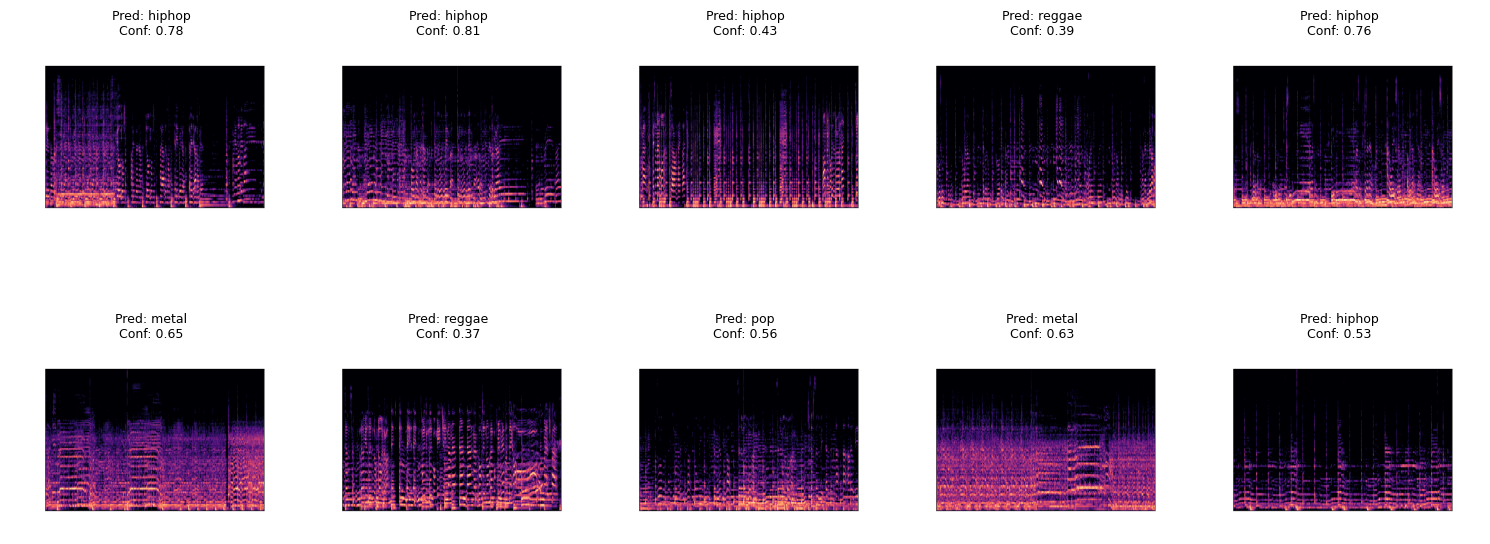

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import  transforms
def predict_folder(model, folder, device, classes):
    model.eval()

    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    # Ambil list file dan sort biar konsisten
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))])

    plt.figure(figsize=(15, 7)) # Diperlebar biar gak sumpek

    for i, f in enumerate(files[:10]):
        img_path = os.path.join(folder, f)
        img = Image.open(img_path).convert("RGB")
        
        # Preprocessing
        x = tfm(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(x)
            p = torch.softmax(output, dim=1)
            conf, idx = p.max(1)

        # Visualisasi
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        
        # Ambil nama class, pastiin classes adalah list string
        label = classes[idx.item()] 
        plt.title(f"Pred: {label}\nConf: {conf.item():.2f}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# PASTIIN INI ADALAH LIST NAMA GENRE, bukan objek dataset-nya
# Contoh: class_names = ['blues', 'classical', ..., 'rock']
class_names = base_dataset.classes 

# Run
predict_folder(
    model,
    "C:/Users/User/Downloads/PORTO/GTZAN Dataset - Music Genre Classification/DataTrain/rock",
    device,
    class_names
)

## Save model

In [14]:
import os

# Bikin folder models dulu kalau takut belum ada
os.makedirs("../models", exist_ok=True)

# Save ke folder models
torch.save(model.state_dict(), "../models/model_music_genre.pth")